In [1]:
#librerias 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split



In [2]:
df = pd.read_parquet("data/listings_clean.parquet")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (76246, 81)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,log_price
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas",4.584967
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas",5.081404
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas",3.663562
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas",4.983607
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas",4.077537


Ingeniería de características 

Se hace esto para seleccionar las variables que podrían servir par predecir los precios de las propiedades.
las variables relacionadas con la capacidad y el tamaño de alojamiento suelen estar relacionadas con el precio, se seleccionaron las siguientes variables 
accommodates

bedrooms

beds

bathrooms



In [3]:
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms"
]

model_data = df[features + ["price"]].dropna()

print("Dataset para modelado:", model_data.shape)

model_data.head()

Dataset para modelado: (76032, 5)


,accommodates,bedrooms,beds,bathrooms,price
0,3,1.0,2.0,1.0,97.0
1,2,1.0,2.0,1.0,160.0
2,2,1.0,1.0,1.0,38.0
3,3,2.0,2.0,2.0,145.0
4,2,1.0,1.0,1.0,58.0


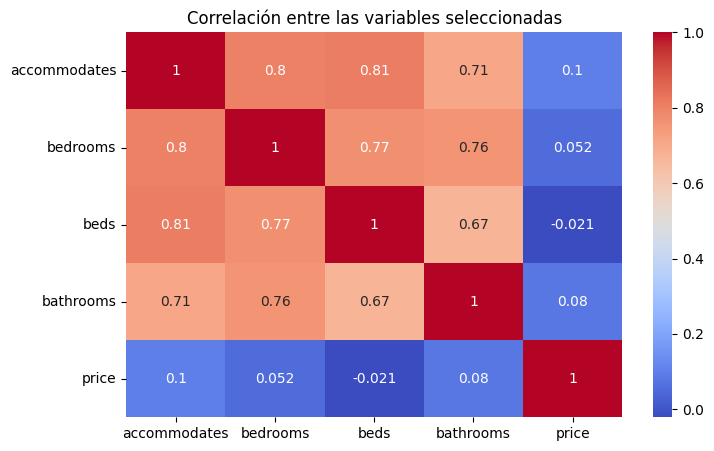

In [4]:
#analisis de correlacion 

corr = model_data.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre las variables seleccionadas")
plt.show()


In [6]:
#división del dataset 

X = model_data[features]
Y = model_data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
)

print("Entrenamiento: ", X_train.shape)
print("Prueba: ", X_test.shape)

Entrenamiento:  (53222, 4)
Prueba:  (22810, 4)


In [8]:
#dataset final 
train_data = X_train.copy()
train_data["price"] = y_train

test_data = X_test.copy()
test_data["price"] = y_test

train_data.head()

,accommodates,bedrooms,beds,bathrooms,price
24052,3,0.0,2.0,1.0,230.0
26207,5,1.0,1.0,1.0,329.0
26355,8,2.0,4.0,2.0,539.0
56003,6,1.0,1.0,1.0,126.0
49106,6,3.0,3.0,2.0,575.0
